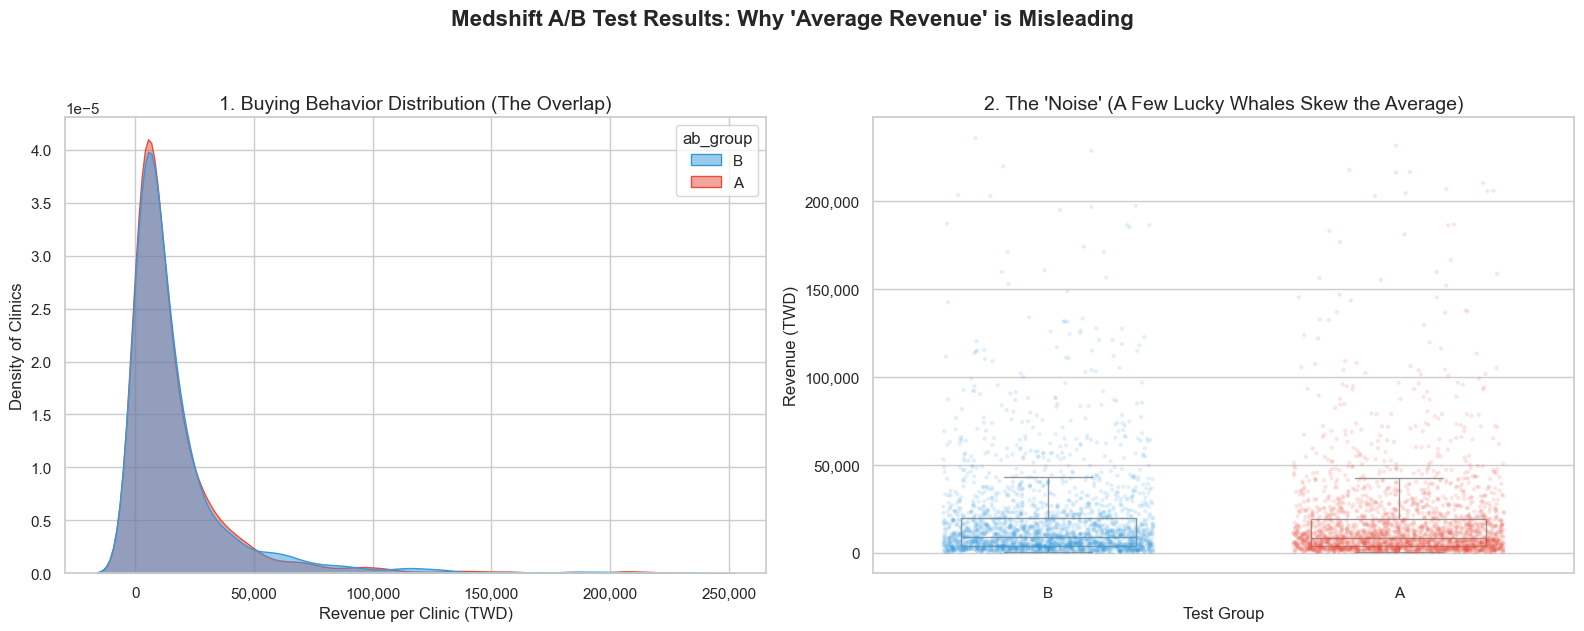

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

# Mute warnings for a clean presentation
warnings.filterwarnings('ignore')

# 1. Load the simulated 5,000-row dataset
file_path = "data/ab_test_5000.csv"
df = pd.read_csv(file_path)

# Set up a professional, clean theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Main Title
fig.suptitle("Medshift A/B Test Results: Why 'Average Revenue' is Misleading", 
             fontsize=16, fontweight='bold', y=1.05)

# --- CHART 1: The Density Curve (KDE) ---
# Goal: Prove that the vast majority of clinics in BOTH groups bought the exact same amount.
sns.kdeplot(data=df, x='revenue_twd', hue='ab_group', fill=True, common_norm=False, 
            palette=['#3498db', '#e74c3c'], alpha=0.5, ax=axes[0])

axes[0].set_title("1. Buying Behavior Distribution (The Overlap)", fontsize=14)
axes[0].set_xlabel("Revenue per Clinic (TWD)")
axes[0].set_ylabel("Density of Clinics")
# Format x-axis with commas for readability (e.g., 200,000 instead of 200000)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))


# --- CHART 2: Boxplot + Data Cloud (Strip Plot) ---
# Goal: Prove that the higher average was driven by a few lucky "whales", not a strategic shift.
sns.boxplot(data=df, x='ab_group', y='revenue_twd', color="white", width=0.5, 
            showfliers=False, ax=axes[1])

# Layer the actual data points over the boxplot to show the "noise"
sns.stripplot(data=df, x='ab_group', y='revenue_twd', hue='ab_group', 
              palette=['#3498db', '#e74c3c'], alpha=0.15, size=3, jitter=0.3, ax=axes[1], legend=False)

axes[1].set_title("2. The 'Noise' (A Few Lucky Whales Skew the Average)", fontsize=14)
axes[1].set_xlabel("Test Group")
axes[1].set_ylabel("Revenue (TWD)")
# Format y-axis with commas
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: format(int(y), ',')))

plt.tight_layout()
plt.show()